# 🩸 Pima Indians Diabetes — Exploratory Data Analysis & Visualization
### Minor Project Part-I: Metabolic & Clinical Profile Exploration
**Dataset:** Pima Indians Diabetes Database (768 patient records, 8 clinical features + 1 target)  
**Tools:** `matplotlib`, `seaborn`, `pandas`, `numpy`  
**Purpose:** Visualize physiological indicators, assess the impact of class-stratified median imputation on biological zero-anomalies, and identify diabetes risk factors.

## 1. Setup & Data Loading
Load both raw data (with physiological zeros) and cleaned data (with median imputation) to illustrate before-and-after distributions.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.autolayout'] = True
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

BASE_DIR = os.getcwd()
CLEAN_DATA_PATH = os.path.join(BASE_DIR, "processed_data", "cleaned_diabetes.csv")
RAW_DATA_PATH = os.path.join(BASE_DIR, "Dataset minor", "pima-indians-diabetes.csv")
VIZ_DIR = os.path.join(BASE_DIR, "visualizations", "diabetes")
os.makedirs(VIZ_DIR, exist_ok=True)

COLUMNS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df_clean = pd.read_csv(CLEAN_DATA_PATH)
df_raw = pd.read_csv(RAW_DATA_PATH, names=COLUMNS)

print(f"Loaded Cleaned Dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
display(df_clean.head())

Loaded Cleaned Dataset: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 2. Target Diagnostic Distribution (`Outcome`)
Analyze the clinical balance of diabetic (`1`) vs non-diabetic (`0`) patients.

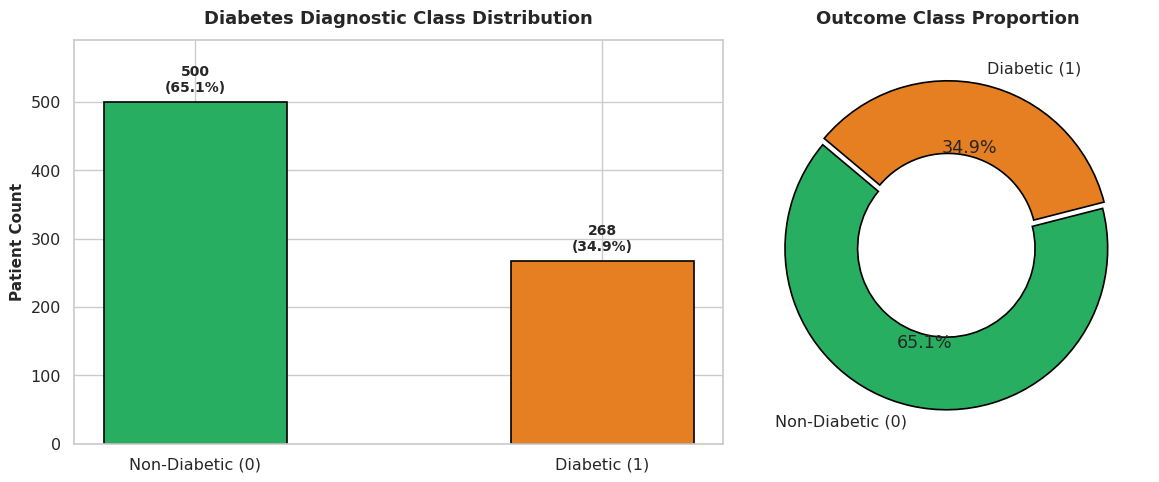

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df_clean['Outcome'].value_counts()
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
ordered_counts = [counts[0], counts[1]]
percentages = [c / len(df_clean) * 100 for c in ordered_counts]
colors = ['#27ae60', '#e67e22']

# 1. Bar Chart
bars = axes[0].bar(labels, ordered_counts, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
axes[0].set_title("Diabetes Diagnostic Class Distribution", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("Patient Count", fontsize=11, fontweight='bold')
for bar, c, pct in zip(bars, ordered_counts, percentages):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                 f"{c}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(ordered_counts) * 1.18)

# 2. Donut Chart
axes[1].pie(ordered_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
            explode=(0.04, 0), wedgeprops=dict(width=0.45, edgecolor='black', linewidth=1.2))
axes[1].set_title("Outcome Class Proportion", fontsize=13, fontweight='bold', pad=12)

plt.savefig(os.path.join(VIZ_DIR, "01_outcome_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Clinical Imputation Validation: Before vs After Imputation
Visualize how Class-Stratified Median Imputation corrected biologically invalid zero values in:
* **Serum Insulin** (zeros imputed with group median: 102.5 for Outcome=0, 169.5 for Outcome=1)
* **SkinThickness** (zeros imputed with group median: 27.0 for Outcome=0, 32.0 for Outcome=1)

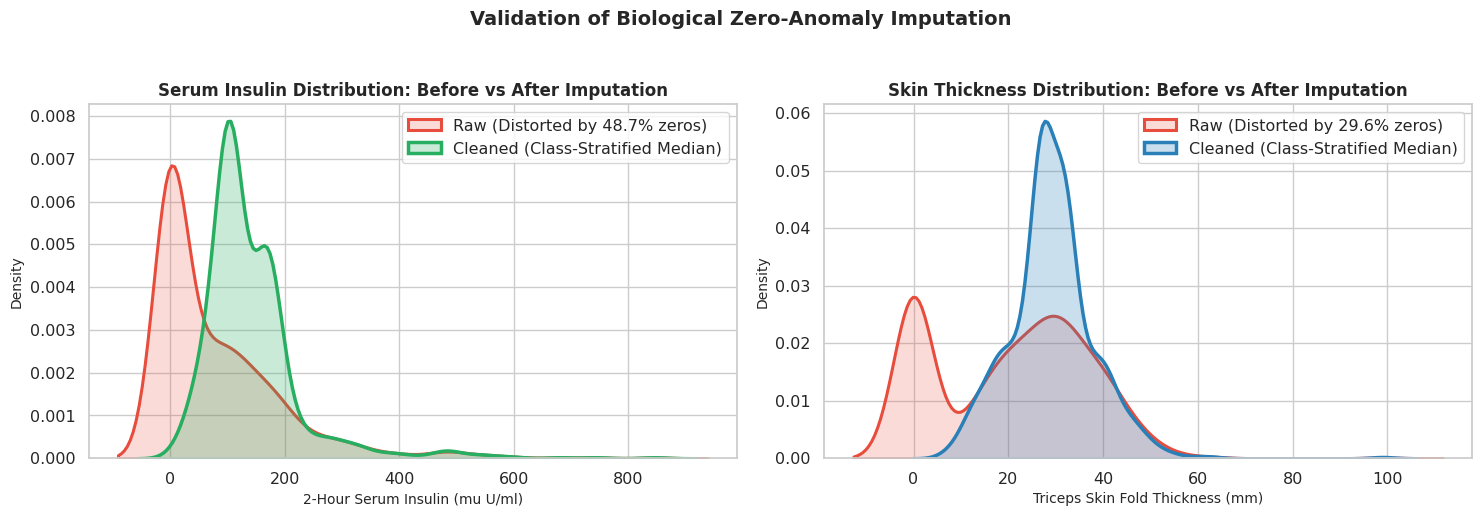

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Insulin Comparison
sns.kdeplot(df_raw['Insulin'], ax=axes[0], label='Raw (Distorted by 48.7% zeros)',
            color='#e74c3c', linewidth=2.2, fill=True, alpha=0.2)
sns.kdeplot(df_clean['Insulin'], ax=axes[0], label='Cleaned (Class-Stratified Median)',
            color='#27ae60', linewidth=2.5, fill=True, alpha=0.25)
axes[0].set_title("Serum Insulin Distribution: Before vs After Imputation", fontsize=12, fontweight='bold')
axes[0].set_xlabel("2-Hour Serum Insulin (mu U/ml)", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend()

# 2. SkinThickness Comparison
sns.kdeplot(df_raw['SkinThickness'], ax=axes[1], label='Raw (Distorted by 29.6% zeros)',
            color='#e74c3c', linewidth=2.2, fill=True, alpha=0.2)
sns.kdeplot(df_clean['SkinThickness'], ax=axes[1], label='Cleaned (Class-Stratified Median)',
            color='#2980b9', linewidth=2.5, fill=True, alpha=0.25)
axes[1].set_title("Skin Thickness Distribution: Before vs After Imputation", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Triceps Skin Fold Thickness (mm)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].legend()

plt.suptitle("Validation of Biological Zero-Anomaly Imputation", fontsize=14, fontweight='bold', y=1.03)
plt.savefig(os.path.join(VIZ_DIR, "02_imputation_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Pearson Correlation Matrix — Metabolic Predictors
Assess linear associations between clinical biomarkers and the diabetes diagnosis.

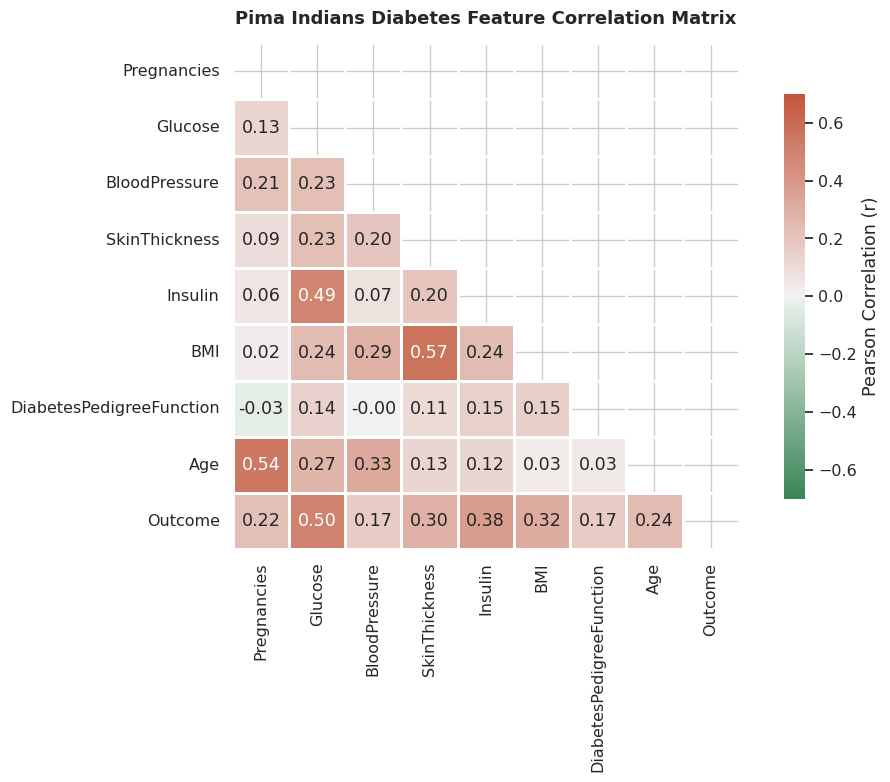

--- Correlation with Diabetes Outcome ---


,Correlation with Outcome
Outcome,1.000000
Glucose,0.495990
Insulin,0.377081
BMI,0.315577
SkinThickness,0.295138
Age,0.238356
Pregnancies,0.221898
BloodPressure,0.174469
DiabetesPedigreeFunction,0.173844


In [4]:
plt.figure(figsize=(10, 8))
corr = df_clean.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(140, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.7, vmin=-.7, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.8,
            cbar_kws={"shrink": .8, "label": "Pearson Correlation (r)"})

plt.title("Pima Indians Diabetes Feature Correlation Matrix", fontsize=13, fontweight='bold', pad=14)
plt.savefig(os.path.join(VIZ_DIR, "03_diabetes_correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

print("--- Correlation with Diabetes Outcome ---")
display(corr['Outcome'].sort_values(ascending=False).to_frame(name="Correlation with Outcome"))

## 5. Glucose vs Insulin: Metabolic Coupling & Insulin Resistance
Analyze the co-dependency between plasma glucose concentration and serum insulin, stratified by diabetes outcome.

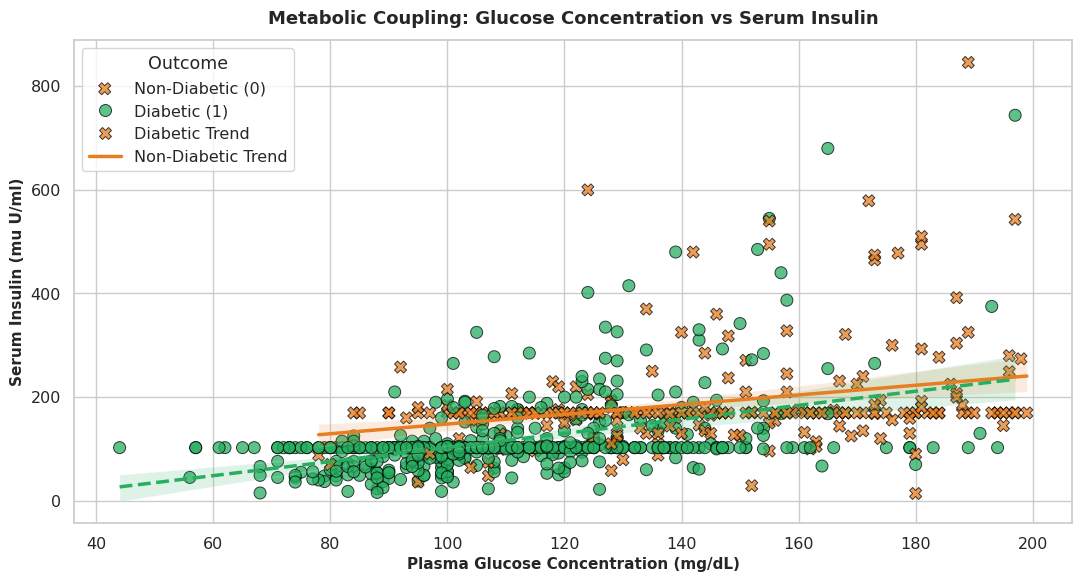

In [5]:
plt.figure(figsize=(11, 6))

sns.scatterplot(data=df_clean, x='Glucose', y='Insulin', hue='Outcome', style='Outcome',
                palette=['#27ae60', '#e67e22'], s=75, alpha=0.75, edgecolor='black')

sns.regplot(data=df_clean[df_clean['Outcome']==1], x='Glucose', y='Insulin', scatter=False,
            color='#e67e22', label='Diabetic Trendline', line_kws={'linewidth': 2.5})
sns.regplot(data=df_clean[df_clean['Outcome']==0], x='Glucose', y='Insulin', scatter=False,
            color='#27ae60', label='Non-Diabetic Trendline', line_kws={'linewidth': 2.5, 'linestyle': '--'})

plt.title("Metabolic Coupling: Glucose Concentration vs Serum Insulin", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Plasma Glucose Concentration (mg/dL)", fontsize=11, fontweight='bold')
plt.ylabel("Serum Insulin (mu U/ml)", fontsize=11, fontweight='bold')
plt.legend(title="Outcome", labels=['Non-Diabetic (0)', 'Diabetic (1)', 'Diabetic Trend', 'Non-Diabetic Trend'])

plt.savefig(os.path.join(VIZ_DIR, "04_glucose_vs_insulin.png"), dpi=300, bbox_inches='tight')
plt.show()

## 6. BMI & Age Distribution Across Diagnostic Cohorts
Examine how Body Mass Index (`BMI`) and patient `Age` interact to escalate diabetes risk.

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_13716\1077928016.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Outcome', y='BMI', ax=axes[0], palette=['#27ae60', '#e67e22'],
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_13716\1077928016.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Outcome', y='Age', ax=axes[1], palette=['#27ae60', '#e67e22'],


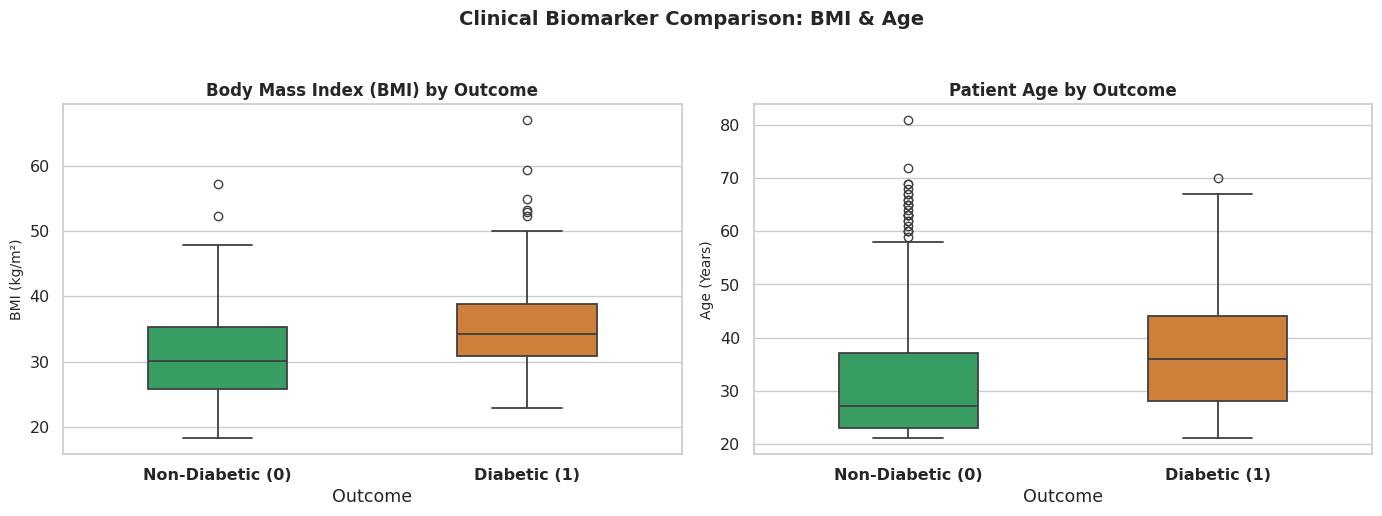

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. BMI Boxplot
sns.boxplot(data=df_clean, x='Outcome', y='BMI', ax=axes[0], palette=['#27ae60', '#e67e22'],
            width=0.45, linewidth=1.3)
axes[0].set_title("Body Mass Index (BMI) by Outcome", fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'], fontweight='bold')
axes[0].set_ylabel("BMI (kg/m²)", fontsize=10)

# 2. Age Boxplot
sns.boxplot(data=df_clean, x='Outcome', y='Age', ax=axes[1], palette=['#27ae60', '#e67e22'],
            width=0.45, linewidth=1.3)
axes[1].set_title("Patient Age by Outcome", fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'], fontweight='bold')
axes[1].set_ylabel("Age (Years)", fontsize=10)

plt.suptitle("Clinical Biomarker Comparison: BMI & Age", fontsize=14, fontweight='bold', y=1.03)
plt.savefig(os.path.join(VIZ_DIR, "05_bmi_and_age_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

## 7. Key Findings in Diabetes Exploration
* **Glucose Concentration:** Strongest single linear predictor ($r = 0.49$) with diabetic patients exhibiting significantly higher mean levels.
* **Insulin Resistance:** Apparent in diabetic patients requiring substantially higher serum insulin for equivalent glucose clearance.
* **BMI & Age:** Elevated BMI (> 32 kg/m²) and older age groups consistently correlate with higher diabetes prevalence.